# APTOS Retinal Grading — ResNet34 150-Epoch Faster Training

This version keeps the complete **150-epoch** ResNet34 training run while reducing wall-clock time mainly through a larger batch and a more efficient GPU/data pipeline.

### Main changes
- **150 epochs retained** — no epoch reduction.
- Training batch increased from **16 → 32** on a typical 16 GB Kaggle GPU.
- Automatic safe batch selection based on available GPU memory.
- Validation/test batch is **2× training batch**.
- Faster but conservative discriminative learning rates for the larger batch:
  - frozen head LR: **4e-4**
  - backbone fine-tuning LR: **4e-5**
  - head fine-tuning LR: **2e-4**
- **ReduceLROnPlateau** still lowers LR automatically when validation QWK stalls.
- **Fused AdamW** is used when the installed PyTorch/CUDA build supports it.
- AMP mixed precision, channels-last tensors, pinned memory, persistent workers, and increased prefetch are retained/enhanced.
- Best EMA checkpoint is saved throughout all 150 epochs, so the final deployed model does not have to be the last epoch.
- **Fresh start only** — training always begins from epoch 1 with the new faster settings.

### Generalization safeguards retained
- ImageNet-pretrained ResNet34
- moderate augmentation
- dropout
- label smoothing
- AdamW weight decay
- EMA
- gradient clipping
- class balancing
- 80/10/10 stratified split
- untouched held-out test set
- best-validation checkpoint selection

> No training configuration can guarantee zero overfitting/underfitting or a fixed test accuracy before the run. This notebook is configured to reduce those risks while keeping the full 150 epochs.


In [1]:
# ============================================================
# 1. Imports, compatibility helpers, reproducibility, GPU speed
# ============================================================
import os
import gc
import cv2
import json
import math
import time
import copy
import random
import warnings
from pathlib import Path
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms as T
from torchvision.models import resnet34
try:
    from torchvision.models import ResNet34_Weights
except ImportError:
    ResNet34_Weights = None

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    cohen_kappa_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

try:
    from scipy.optimize import minimize
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
cv2.setNumThreads(0)

SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True
        try:
            torch.backends.cuda.matmul.allow_tf32 = True
            torch.backends.cudnn.allow_tf32 = True
        except Exception:
            pass

seed_everything(SEED)

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"

def autocast_context():
    if DEVICE.type != "cuda":
        return nullcontext()
    try:
        return torch.amp.autocast(device_type="cuda", dtype=torch.float16)
    except (AttributeError, TypeError):
        return torch.cuda.amp.autocast()

def make_grad_scaler():
    enabled = DEVICE.type == "cuda"
    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=enabled)

def safe_torch_load(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: CUDA GPU not detected. Enable a Kaggle GPU before training.")


PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
Device: cuda
GPU: Tesla T4


In [2]:
# ============================================================
# 2. Configuration — 1 epoch test run
# ============================================================
def choose_fast_batch_size():
    """
    Conservative automatic batch selection for 300x300 ResNet34 + AMP.
    Typical Kaggle T4/P100 (about 16 GB) -> batch 32.
    """
    if not torch.cuda.is_available():
        return 8

    total_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)

    if total_gb >= 30:
        return 48
    elif total_gb >= 14:
        return 32
    elif total_gb >= 10:
        return 24
    else:
        return 16

AUTO_BATCH_SIZE = choose_fast_batch_size()

CFG = {
    "seed": 42,
    "model_name": "resnet34",
    "img_size": 300,

    # Data loading
    "batch_size": AUTO_BATCH_SIZE,
    "num_workers": min(4, max(1, os.cpu_count() or 2)),
    "prefetch_factor": 4,

    "n_classes": 5,

    # Labeled split: 80% train / 10% validation / 10% untouched test
    "val_size": 0.10,
    "heldout_test_size": 0.10,

    # Training length (set to 150 for the full run)
    "epochs": 150,
    "freeze_epochs": 3,

    # Early stopping disabled; best validation checkpoint is saved
    "early_stop_patience": 9999,
    "early_stop_min_delta": 0.0010,

    # Learning rates
    "frozen_head_lr": 4e-4,
    "backbone_lr": 4e-5,
    "finetune_head_lr": 2e-4,

    # Adaptive LR reduction if validation QWK stalls
    "lr_factor": 0.50,
    "lr_patience": 2,
    "lr_threshold": 0.0010,
    "min_backbone_lr": 8e-7,
    "min_head_lr": 4e-6,

    # Generalization controls
    "weight_decay": 3e-4,
    "dropout": 0.35,
    "label_smoothing": 0.05,
    "grad_clip": 1.0,
    "ema_decay": 0.999,

    # Dual-task loss
    "cls_loss_weight": 0.75,
    "reg_loss_weight": 0.25,

    # Continuous ordinal prediction blend
    "cls_pred_weight": 0.75,
    "reg_pred_weight": 0.25,

    "use_imagenet_pretrained": True,
    "allow_random_init_fallback": True,
    "crop_black_border": True,
    "tta": True,

    # Resume settings
    "resume": False,
    "resume_weights_only": False,
}

# ------------------------------------------------------------
# Output paths
# ------------------------------------------------------------
OUTPUT_DIR = Path("/kaggle/working/aptos_resnet34_fast")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BEST_WEIGHTS_PATH = Path("/kaggle/working/aptos_resnet34_fast_best_weights.pth")
BEST_VAL_WEIGHTS_PATH = Path("/kaggle/working/aptos_resnet34_fast_best_val_loss_weights.pth")
FINAL_WEIGHTS_PATH = Path("/kaggle/working/aptos_resnet34_fast_last_epoch_weights.pth")

with open(OUTPUT_DIR / "config.json", "w") as f:
    json.dump(CFG, f, indent=2)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print(json.dumps(CFG, indent=2))
print("Output directory:", OUTPUT_DIR)
print(f"Selected training batch size: {CFG['batch_size']}")

if torch.cuda.is_available():
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f"GPU memory: {gpu_mem:.1f} GB")

{
  "seed": 42,
  "model_name": "resnet34",
  "img_size": 300,
  "batch_size": 32,
  "num_workers": 4,
  "prefetch_factor": 4,
  "n_classes": 5,
  "val_size": 0.1,
  "heldout_test_size": 0.1,
  "epochs": 150,
  "freeze_epochs": 3,
  "early_stop_patience": 9999,
  "early_stop_min_delta": 0.001,
  "frozen_head_lr": 0.0004,
  "backbone_lr": 4e-05,
  "finetune_head_lr": 0.0002,
  "lr_factor": 0.5,
  "lr_patience": 2,
  "lr_threshold": 0.001,
  "min_backbone_lr": 8e-07,
  "min_head_lr": 4e-06,
  "weight_decay": 0.0003,
  "dropout": 0.35,
  "label_smoothing": 0.05,
  "grad_clip": 1.0,
  "ema_decay": 0.999,
  "cls_loss_weight": 0.75,
  "reg_loss_weight": 0.25,
  "cls_pred_weight": 0.75,
  "reg_pred_weight": 0.25,
  "use_imagenet_pretrained": true,
  "allow_random_init_fallback": true,
  "crop_black_border": true,
  "tta": true,
  "resume": false,
  "resume_weights_only": false
}
Output directory: /kaggle/working/aptos_resnet34_fast
Selected training batch size: 32
GPU memory: 14.6 GB


In [3]:
# ============================================================
# 3. Robustly locate the APTOS dataset
# ============================================================
INPUT_ROOT = Path("/kaggle/input")
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def csv_has_columns(path, required):
    try:
        x = pd.read_csv(path, nrows=5)
        return set(required).issubset(x.columns)
    except Exception:
        return False

def image_stems(folder):
    if folder is None or not folder.exists():
        return set()
    return {
        p.stem for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    }

train_csv_candidates = [
    p for p in INPUT_ROOT.rglob("train.csv")
    if csv_has_columns(p, ["id_code", "diagnosis"])
]
train_image_dirs = [p for p in INPUT_ROOT.rglob("train_images") if p.is_dir()]

if not train_csv_candidates:
    raise FileNotFoundError(
        "Could not find a train.csv containing id_code and diagnosis under /kaggle/input."
    )
if not train_image_dirs:
    raise FileNotFoundError(
        "Could not find a train_images directory under /kaggle/input."
    )

best_pair = None
best_score = -1

dir_stem_cache = {str(d): image_stems(d) for d in train_image_dirs}

for csv_path in train_csv_candidates:
    probe = pd.read_csv(csv_path, usecols=["id_code", "diagnosis"], nrows=30)
    probe_ids = set(probe["id_code"].astype(str))
    for img_dir in train_image_dirs:
        score = len(probe_ids.intersection(dir_stem_cache[str(img_dir)]))
        if score > best_score:
            best_score = score
            best_pair = (csv_path, img_dir)

train_csv, TRAIN_IMG_DIR = best_pair

if best_score <= 0:
    raise FileNotFoundError(
        "Found APTOS-like CSV/image folders, but image IDs did not match. "
        "Please attach the correct dataset."
    )

DATA_DIR = train_csv.parent

# Prefer files adjacent to the selected train.csv.
test_csv = DATA_DIR / "test.csv"
if not (test_csv.exists() and csv_has_columns(test_csv, ["id_code"])):
    candidates = [
        p for p in INPUT_ROOT.rglob("test.csv")
        if csv_has_columns(p, ["id_code"])
    ]
    test_csv = candidates[0] if candidates else None

sample_csv = DATA_DIR / "sample_submission.csv"
if not (sample_csv.exists() and csv_has_columns(sample_csv, ["id_code", "diagnosis"])):
    candidates = [
        p for p in INPUT_ROOT.rglob("sample_submission.csv")
        if csv_has_columns(p, ["id_code", "diagnosis"])
    ]
    sample_csv = candidates[0] if candidates else None

test_dirs = [p for p in INPUT_ROOT.rglob("test_images") if p.is_dir()]
TEST_IMG_DIR = None

if test_csv is not None and test_dirs:
    probe = pd.read_csv(test_csv, usecols=["id_code"], nrows=30)
    probe_ids = set(probe["id_code"].astype(str))
    scored = []
    for d in test_dirs:
        scored.append((len(probe_ids.intersection(image_stems(d))), d))
    scored.sort(key=lambda x: x[0], reverse=True)
    if scored and scored[0][0] > 0:
        TEST_IMG_DIR = scored[0][1]

print("train.csv:", train_csv)
print("train_images:", TRAIN_IMG_DIR)
print("Matching probe images:", best_score)
print("test.csv:", test_csv)
print("test_images:", TEST_IMG_DIR)
print("sample_submission.csv:", sample_csv)

train.csv: /kaggle/input/competitions/aptos2019-blindness-detection/train.csv
train_images: /kaggle/input/competitions/aptos2019-blindness-detection/train_images
Matching probe images: 30
test.csv: /kaggle/input/competitions/aptos2019-blindness-detection/test.csv
test_images: /kaggle/input/competitions/aptos2019-blindness-detection/test_images
sample_submission.csv: /kaggle/input/competitions/aptos2019-blindness-detection/sample_submission.csv


In [4]:
# ============================================================
# 4. Load data and create leakage-safe 80/10/10 stratified split
# ============================================================
def build_image_index(folder):
    index = {}
    if folder is None:
        return index
    for p in folder.iterdir():
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            index[p.stem] = str(p)
    return index

train_image_index = build_image_index(TRAIN_IMG_DIR)
test_image_index = build_image_index(TEST_IMG_DIR)

train_df = pd.read_csv(train_csv).copy()
train_df["id_code"] = train_df["id_code"].astype(str)
train_df["diagnosis"] = train_df["diagnosis"].astype(int)
train_df["image_path"] = train_df["id_code"].map(train_image_index)

missing_train = train_df["image_path"].isna().sum()
if missing_train:
    examples = train_df.loc[train_df["image_path"].isna(), "id_code"].head(10).tolist()
    raise FileNotFoundError(
        f"{missing_train} training images are missing. Example IDs: {examples}"
    )

if not train_df["diagnosis"].between(0, CFG["n_classes"] - 1).all():
    raise ValueError("Diagnosis labels must be integers from 0 to 4.")

# Official APTOS test set, if present, is retained for submission inference.
official_test_df = None
if test_csv is not None and TEST_IMG_DIR is not None:
    official_test_df = pd.read_csv(test_csv).copy()
    official_test_df["id_code"] = official_test_df["id_code"].astype(str)
    official_test_df["image_path"] = official_test_df["id_code"].map(test_image_index)
    missing_test = official_test_df["image_path"].isna().sum()
    if missing_test:
        print(f"WARNING: {missing_test} official test images were not found; submission generation will be skipped.")
        official_test_df = None

print("Total labeled images:", len(train_df))
display(train_df.head())

counts = train_df["diagnosis"].value_counts().sort_index()
display(pd.DataFrame({
    "count": counts,
    "percent": (counts / len(train_df) * 100).round(2),
}))

if len(counts) != CFG["n_classes"]:
    raise ValueError(
        f"Expected all {CFG['n_classes']} classes, but found {len(counts)}."
    )

# First reserve a completely untouched 10% held-out test set.
trainval_df, heldout_df = train_test_split(
    train_df,
    test_size=CFG["heldout_test_size"],
    random_state=CFG["seed"],
    stratify=train_df["diagnosis"],
)

# Then take 10% of the TOTAL dataset for validation.
val_fraction_of_trainval = CFG["val_size"] / (1.0 - CFG["heldout_test_size"])

tr_df, va_df = train_test_split(
    trainval_df,
    test_size=val_fraction_of_trainval,
    random_state=CFG["seed"] + 1,
    stratify=trainval_df["diagnosis"],
)

tr_df = tr_df.reset_index(drop=True)
va_df = va_df.reset_index(drop=True)
heldout_df = heldout_df.reset_index(drop=True)

split_df = pd.concat([
    tr_df.assign(split="train"),
    va_df.assign(split="validation"),
    heldout_df.assign(split="heldout_test"),
], ignore_index=True)

split_df[["id_code", "diagnosis", "split"]].to_csv(
    OUTPUT_DIR / "data_split.csv", index=False
)

print(f"Train:        {len(tr_df)} ({len(tr_df)/len(train_df):.1%})")
print(f"Validation:   {len(va_df)} ({len(va_df)/len(train_df):.1%})")
print(f"Held-out test:{len(heldout_df)} ({len(heldout_df)/len(train_df):.1%})")

for name, frame in [("TRAIN", tr_df), ("VALIDATION", va_df), ("HELD-OUT TEST", heldout_df)]:
    print(f"\n{name} class distribution")
    display(frame["diagnosis"].value_counts().sort_index().to_frame("count"))

# Compatibility alias used later for official Kaggle submission.
test_df = official_test_df


Total labeled images: 3662


,id_code,diagnosis,image_path
0,000c1434d8d7,2,/kaggle/input/competitions/aptos2019-blindness...
1,001639a390f0,4,/kaggle/input/competitions/aptos2019-blindness...
2,0024cdab0c1e,1,/kaggle/input/competitions/aptos2019-blindness...
3,002c21358ce6,0,/kaggle/input/competitions/aptos2019-blindness...
4,005b95c28852,0,/kaggle/input/competitions/aptos2019-blindness...


,count,percent
diagnosis,,
0,1805,49.29
1,370,10.10
2,999,27.28
3,193,5.27
4,295,8.06


Train:        2928 (80.0%)
Validation:   367 (10.0%)
Held-out test:367 (10.0%)

TRAIN class distribution


,count
diagnosis,
0,1443
1,296
2,799
3,155
4,235



VALIDATION class distribution


,count
diagnosis,
0,181
1,37
2,100
3,19
4,30



HELD-OUT TEST class distribution


,count
diagnosis,
0,181
1,37
2,100
3,19
4,30


In [5]:
# ============================================================
# 5. Stable, moderated class weights
# ============================================================
classes = np.arange(CFG["n_classes"])
train_counts = np.bincount(
    tr_df["diagnosis"].values,
    minlength=CFG["n_classes"]
).astype(np.float32)

if np.any(train_counts == 0):
    raise ValueError("At least one DR grade is missing from the training split.")

# Full inverse-frequency weights can over-correct class imbalance and reduce
# overall accuracy. Square-root inverse weighting is more conservative.
raw_weights = len(tr_df) / (CFG["n_classes"] * train_counts)
class_weights_np = np.sqrt(raw_weights)
class_weights_np = class_weights_np / class_weights_np.mean()
class_weights_np = np.clip(class_weights_np, 0.60, 1.80)

class_weights = torch.tensor(
    class_weights_np,
    dtype=torch.float32,
    device=DEVICE
)

display(pd.DataFrame({
    "class": classes,
    "train_count": train_counts.astype(int),
    "class_weight": class_weights_np,
}))


,class,train_count,class_weight
0,0,1443,0.600000
1,1,296,1.095102
2,2,799,0.666541
3,3,155,1.513333
4,4,235,1.229041


In [6]:
# ============================================================
# 6. Retina preprocessing and conservative augmentation
# ============================================================
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

def crop_black(img, tol=7):
    if img.ndim == 2:
        mask = img > tol
    else:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray > tol

    if not mask.any():
        return img

    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    y1, y2 = rows[0], rows[-1] + 1
    x1, x2 = cols[0], cols[-1] + 1
    return img[y1:y2, x1:x2]

train_tfms = T.Compose([
    T.Resize((CFG["img_size"], CFG["img_size"])),
    T.RandomHorizontalFlip(p=0.50),
    T.RandomVerticalFlip(p=0.10),
    T.RandomRotation(degrees=15, fill=0),
    T.RandomAffine(
        degrees=0,
        translate=(0.025, 0.025),
        scale=(0.96, 1.04),
        shear=(-2, 2),
        fill=0,
    ),
    T.ColorJitter(
        brightness=0.08,
        contrast=0.10,
        saturation=0.05,
        hue=0.015,
    ),
    T.RandomApply(
        [T.GaussianBlur(kernel_size=3, sigma=(0.1, 0.8))],
        p=0.03,
    ),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

valid_tfms = T.Compose([
    T.Resize((CFG["img_size"], CFG["img_size"])),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print(train_tfms)


Compose(
    Resize(size=(300, 300), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.1)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    RandomAffine(degrees=[0.0, 0.0], translate=(0.025, 0.025), scale=(0.96, 1.04), shear=[-2.0, 2.0])
    ColorJitter(brightness=(0.92, 1.08), contrast=(0.9, 1.1), saturation=(0.95, 1.05), hue=(-0.015, 0.015))
    RandomApply(
    p=0.03
    GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 0.8))
)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)


In [7]:
# ============================================================
# 7. Dataset and efficient DataLoaders
# ============================================================
class AptosDataset(Dataset):
    def __init__(self, df, transforms=None, is_test=False):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = cv2.imread(row["image_path"], cv2.IMREAD_COLOR)
        if image is None:
            raise FileNotFoundError(row["image_path"])

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if CFG["crop_black_border"]:
            image = crop_black(image)

        image = Image.fromarray(image)

        if self.transforms is not None:
            image = self.transforms(image)

        if self.is_test:
            return image, row["id_code"]

        target = int(row["diagnosis"])
        return image, torch.tensor(target, dtype=torch.long)

def make_loader(dataset, batch_size, shuffle, drop_last=False):
    kwargs = dict(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=CFG["num_workers"],
        pin_memory=PIN_MEMORY,
        drop_last=drop_last,
    )
    if CFG["num_workers"] > 0:
        kwargs["persistent_workers"] = True
        kwargs["prefetch_factor"] = CFG["prefetch_factor"]
    return DataLoader(**kwargs)

train_ds = AptosDataset(tr_df, train_tfms, is_test=False)
valid_ds = AptosDataset(va_df, valid_tfms, is_test=False)
heldout_ds = AptosDataset(heldout_df, valid_tfms, is_test=False)

train_loader = make_loader(
    train_ds, CFG["batch_size"], shuffle=True, drop_last=True
)
valid_loader = make_loader(
    valid_ds, CFG["batch_size"] * 2, shuffle=False, drop_last=False
)
heldout_loader = make_loader(
    heldout_ds, CFG["batch_size"] * 2, shuffle=False, drop_last=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(valid_loader))
print("Held-out test batches:", len(heldout_loader))

sample_images, sample_targets = next(iter(train_loader))
print("Batch image shape:", tuple(sample_images.shape))
print("Batch target shape:", tuple(sample_targets.shape))

if sample_images.ndim != 4 or sample_images.shape[1] != 3:
    raise RuntimeError("Unexpected image tensor shape from DataLoader.")


Train batches: 91
Validation batches: 6
Held-out test batches: 6
Batch image shape: (32, 3, 300, 300)
Batch target shape: (32,)


In [8]:
# ============================================================
# 8. ResNet34 dual-head model
# ============================================================
def create_backbone(use_pretrained=True, allow_fallback=True):
    pretrained_loaded = False

    if use_pretrained:
        try:
            if ResNet34_Weights is not None:
                backbone = resnet34(
                    weights=ResNet34_Weights.IMAGENET1K_V1
                )
            else:
                backbone = resnet34(pretrained=True)
            pretrained_loaded = True
            print("Loaded ImageNet-pretrained ResNet34 weights.")
        except Exception as e:
            if not allow_fallback:
                raise RuntimeError(
                    "Could not load pretrained ResNet34 weights. "
                    f"Original error: {e}"
                )
            print("WARNING: pretrained ResNet34 weights could not be loaded.")
            print("Falling back to random initialization.")
            print("Pretrained-load error:", repr(e))
            try:
                backbone = resnet34(weights=None)
            except TypeError:
                backbone = resnet34(pretrained=False)
    else:
        try:
            backbone = resnet34(weights=None)
        except TypeError:
            backbone = resnet34(pretrained=False)

    return backbone, pretrained_loaded


class AptosResNet34(nn.Module):
    def __init__(
        self,
        n_classes=5,
        dropout=0.35,
        use_pretrained=True,
        allow_fallback=True,
    ):
        super().__init__()

        self.backbone, self.pretrained_loaded = create_backbone(
            use_pretrained=use_pretrained,
            allow_fallback=allow_fallback,
        )

        n_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.dropout = nn.Dropout(dropout)
        self.cls_head = nn.Linear(n_features, n_classes)

        self.reg_head = nn.Sequential(
            nn.Linear(n_features, 256),
            nn.SiLU(),
            nn.Dropout(dropout * 0.65),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        feat = self.backbone(x)
        feat = self.dropout(feat)
        logits = self.cls_head(feat)
        severity = self.reg_head(feat).squeeze(1)
        return logits, severity


model = AptosResNet34(
    n_classes=CFG["n_classes"],
    dropout=CFG["dropout"],
    use_pretrained=CFG["use_imagenet_pretrained"],
    allow_fallback=CFG["allow_random_init_fallback"],
).to(DEVICE)

if DEVICE.type == "cuda":
    model = model.to(memory_format=torch.channels_last)

n_total = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_total / 1e6:.2f}M")
print("Pretrained weights loaded:", model.pretrained_loaded)

if not model.pretrained_loaded:
    CFG["freeze_epochs"] = 0
    CFG["backbone_lr"] = 1e-4
    print("Fallback mode: freeze_epochs changed to 0 and backbone_lr to 1e-4.")
    with open(OUTPUT_DIR / "config.json", "w") as f:
        json.dump(CFG, f, indent=2)

model.eval()
with torch.no_grad():
    smoke = torch.zeros(
        2, 3, CFG["img_size"], CFG["img_size"], device=DEVICE
    )
    if DEVICE.type == "cuda":
        smoke = smoke.contiguous(memory_format=torch.channels_last)
    smoke_logits, smoke_reg = model(smoke)

assert smoke_logits.shape == (2, CFG["n_classes"])
assert smoke_reg.shape == (2,)
print("Architecture smoke test: PASSED")
del smoke, smoke_logits, smoke_reg
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 121MB/s]


Loaded ImageNet-pretrained ResNet34 weights.
Total parameters: 21.42M
Pretrained weights loaded: True
Architecture smoke test: PASSED


In [9]:
# ============================================================
# 9. Loss, faster optimizer, EMA, and adaptive LR scheduler
# ============================================================
classification_loss = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=CFG["label_smoothing"],
)

def regression_loss_weighted(pred, target):
    target_f = target.float()
    per_sample = F.smooth_l1_loss(
        pred,
        target_f,
        beta=0.5,
        reduction="none",
    )
    sample_w = class_weights[target]
    return (per_sample * sample_w).mean()

def total_loss_fn(logits, severity, target):
    l_cls = classification_loss(logits, target)
    l_reg = regression_loss_weighted(severity, target)
    total = (
        CFG["cls_loss_weight"] * l_cls
        + CFG["reg_loss_weight"] * l_reg
    )
    return total, l_cls.detach(), l_reg.detach()

def set_backbone_trainable(model_to_change, trainable):
    for p in model_to_change.backbone.parameters():
        p.requires_grad = trainable

if model.pretrained_loaded and CFG["freeze_epochs"] > 0:
    set_backbone_trainable(model, False)
else:
    set_backbone_trainable(model, True)

initial_backbone_lr = CFG["backbone_lr"]
initial_head_lr = (
    CFG["finetune_head_lr"]
    if CFG["freeze_epochs"] == 0
    else CFG["frozen_head_lr"]
)

optimizer_groups = [
    {
        "params": model.backbone.parameters(),
        "lr": initial_backbone_lr,
        "weight_decay": CFG["weight_decay"],
    },
    {
        "params": list(model.cls_head.parameters()) + list(model.reg_head.parameters()),
        "lr": initial_head_lr,
        "weight_decay": CFG["weight_decay"],
    },
]

# Fused AdamW can reduce optimizer overhead on supported CUDA/PyTorch builds.
try:
    optimizer = torch.optim.AdamW(
        optimizer_groups,
        fused=(DEVICE.type == "cuda"),
    )
    print("AdamW fused mode:", DEVICE.type == "cuda")
except (TypeError, RuntimeError):
    optimizer = torch.optim.AdamW(optimizer_groups)
    print("Fused AdamW unavailable; standard AdamW is being used.")

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=CFG["lr_factor"],
    patience=CFG["lr_patience"],
    threshold=CFG["lr_threshold"],
    threshold_mode="abs",
    min_lr=[CFG["min_backbone_lr"], CFG["min_head_lr"]],
)

scaler = make_grad_scaler()

class ModelEMA:
    def __init__(self, source_model, decay=0.999):
        self.module = copy.deepcopy(source_model).eval()
        self.decay = float(decay)
        for p in self.module.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, source_model):
        source_state = source_model.state_dict()
        ema_state = self.module.state_dict()
        for key, ema_value in ema_state.items():
            source_value = source_state[key].detach()
            if ema_value.dtype.is_floating_point:
                ema_value.mul_(self.decay).add_(
                    source_value,
                    alpha=1.0 - self.decay,
                )
            else:
                ema_value.copy_(source_value)

model_ema = ModelEMA(model, decay=CFG["ema_decay"])

print("Optimizer, ReduceLROnPlateau scheduler, AMP scaler and EMA initialized.")
print("Initial backbone LR:", optimizer.param_groups[0]["lr"])
print("Initial head LR:", optimizer.param_groups[1]["lr"])


AdamW fused mode: True
Optimizer, ReduceLROnPlateau scheduler, AMP scaler and EMA initialized.
Initial backbone LR: 4e-05
Initial head LR: 0.0004


In [10]:
# ============================================================
# 10. Metrics and continuous ordinal prediction
# ============================================================
def blend_continuous_predictions(logits, severity):
    probs = torch.softmax(logits, dim=1)

    grades = torch.arange(
        CFG["n_classes"],
        device=logits.device,
        dtype=probs.dtype,
    )

    expected_grade = (
        probs * grades.unsqueeze(0)
    ).sum(dim=1)

    reg_grade = severity.clamp(0.0, float(CFG["n_classes"] - 1))

    pred = (
        CFG["cls_pred_weight"] * expected_grade
        + CFG["reg_pred_weight"] * reg_grade
    )

    return pred.clamp(0.0, float(CFG["n_classes"] - 1))

def round_default(x):
    return np.clip(
        np.rint(x),
        0,
        CFG["n_classes"] - 1,
    ).astype(int)

def qwk_score(y_true, y_pred):
    score = cohen_kappa_score(
        y_true,
        y_pred,
        weights="quadratic",
    )
    return float(score) if np.isfinite(score) else -1.0

def evaluate_from_continuous(y_true, continuous):
    pred = round_default(continuous)

    return {
        "qwk": qwk_score(y_true, pred),
        "accuracy": float(accuracy_score(y_true, pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, pred)),
        "macro_f1": float(
            f1_score(
                y_true,
                pred,
                average="macro",
                zero_division=0,
            )
        ),
    }

In [11]:
# ============================================================
# 11. Train and validation functions
# ============================================================
def move_images(images):
    images = images.to(DEVICE, non_blocking=True)
    if DEVICE.type == "cuda":
        images = images.contiguous(memory_format=torch.channels_last)
    return images

def train_one_epoch(model_to_train, loader, optimizer, epoch):
    model_to_train.train()

    if epoch < CFG["freeze_epochs"] and model.pretrained_loaded:
        model_to_train.backbone.eval()

    running_loss = 0.0
    running_cls = 0.0
    running_reg = 0.0

    pbar = tqdm(
        loader,
        desc=f"Train {epoch + 1:03d}/{CFG['epochs']}",
    )

    for step, (images, targets) in enumerate(pbar):
        images = move_images(images)
        targets = targets.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast_context():
            logits, severity = model_to_train(images)
            loss, l_cls, l_reg = total_loss_fn(
                logits, severity, targets
            )

        if not torch.isfinite(loss):
            raise RuntimeError(
                f"Non-finite loss at epoch {epoch + 1}, step {step + 1}."
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model_to_train.parameters(),
            CFG["grad_clip"],
        )

        scaler.step(optimizer)
        scaler.update()
        model_ema.update(model_to_train)

        running_loss += float(loss.item())
        running_cls += float(l_cls.item())
        running_reg += float(l_reg.item())

        pbar.set_postfix({
            "loss": f"{running_loss / (step + 1):.4f}",
            "bb_lr": f"{optimizer.param_groups[0]['lr']:.1e}",
            "head_lr": f"{optimizer.param_groups[1]['lr']:.1e}",
        })

    n = max(1, len(loader))
    return (
        running_loss / n,
        running_cls / n,
        running_reg / n,
    )


@torch.no_grad()
def validate(model_to_eval, loader):
    model_to_eval.eval()

    losses = []
    y_true = []
    continuous_preds = []
    classifier_preds = []

    for images, targets in tqdm(
        loader,
        desc="Evaluate",
        leave=False,
    ):
        images = move_images(images)
        targets = targets.to(DEVICE, non_blocking=True)

        with autocast_context():
            logits, severity = model_to_eval(images)
            loss, _, _ = total_loss_fn(
                logits, severity, targets
            )
            cont = blend_continuous_predictions(
                logits, severity
            )

        losses.append(float(loss.item()))
        y_true.extend(targets.cpu().numpy().tolist())
        continuous_preds.extend(cont.float().cpu().numpy().tolist())
        classifier_preds.extend(
            torch.argmax(logits, dim=1).cpu().numpy().tolist()
        )

    y_true = np.asarray(y_true, dtype=np.int64)
    continuous_preds = np.asarray(continuous_preds, dtype=np.float32)
    classifier_preds = np.asarray(classifier_preds, dtype=np.int64)

    metrics = evaluate_from_continuous(
        y_true, continuous_preds
    )
    metrics["loss"] = float(np.mean(losses))
    metrics["classifier_accuracy"] = float(
        accuracy_score(y_true, classifier_preds)
    )
    metrics["classifier_qwk"] = qwk_score(
        y_true, classifier_preds
    )

    return metrics, y_true, continuous_preds, classifier_preds


# Real-batch smoke test
model.train()
images_smoke, targets_smoke = next(iter(train_loader))
images_smoke = move_images(images_smoke[:2])
targets_smoke = targets_smoke[:2].to(DEVICE)

with torch.no_grad():
    with autocast_context():
        logits_smoke, reg_smoke = model(images_smoke)
        loss_smoke, _, _ = total_loss_fn(
            logits_smoke, reg_smoke, targets_smoke
        )

if not torch.isfinite(loss_smoke):
    raise RuntimeError("Pre-training real-batch loss smoke test failed.")

print("Real-batch forward/loss smoke test: PASSED")
print("Smoke loss:", float(loss_smoke.item()))

del images_smoke, targets_smoke, logits_smoke, reg_smoke, loss_smoke
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Real-batch forward/loss smoke test: PASSED
Smoke loss: 2.755398750305176


In [12]:
# ============================================================
# 12. Checkpoint helpers — FRESH START ONLY
# ============================================================
BEST_PATH = OUTPUT_DIR / "best_full_checkpoint.pth"
LAST_PATH = OUTPUT_DIR / "last_full_checkpoint.pth"
HISTORY_PATH = OUTPUT_DIR / "training_history.csv"

def save_full_checkpoint(
    path,
    epoch,
    best_qwk,
    best_val_loss,
    best_qwk_epoch,
    best_val_epoch,
    history,
    no_improve_epochs,
):
    torch.save({
        "epoch": int(epoch),
        "model": model.state_dict(),
        "model_ema": model_ema.module.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict(),
        "best_qwk": float(best_qwk),
        "best_val_loss": float(best_val_loss),
        "best_qwk_epoch": best_qwk_epoch,
        "best_val_epoch": best_val_epoch,
        "history": history,
        "no_improve_epochs": int(no_improve_epochs),
        "config": CFG,
        "class_weights": class_weights_np.tolist(),
        "pretrained_loaded": bool(model.pretrained_loaded),
    }, path)

# Always begin from epoch 1.
start_epoch = 1
best_qwk = -float("inf")
best_val_loss = float("inf")
best_qwk_epoch = None
best_val_epoch = None
history = []
no_improve_epochs = 0

print("Fresh training run selected.")
print("Training will start from epoch 1 and continue through epoch 150.")


Fresh training run selected.
Training will start from epoch 1 and continue through epoch 150.


In [13]:
# ============================================================
# 13. Adaptive training loop with early stopping
# ============================================================
print("=" * 80)
print(f"Training epochs: {CFG['epochs']} (full run)")
print(f"Frozen-backbone epochs: {CFG['freeze_epochs']}")
print("Early stopping: DISABLED — full 150 epochs retained; best validation checkpoint is saved")
print("The best EMA model is preserved automatically.")
print("=" * 80)

last_epoch_completed = start_epoch - 1

for epoch in range(start_epoch, CFG["epochs"]):

    if epoch == CFG["freeze_epochs"] and model.pretrained_loaded:
        set_backbone_trainable(model, True)

        optimizer.param_groups[0]["lr"] = CFG["backbone_lr"]
        optimizer.param_groups[1]["lr"] = CFG["finetune_head_lr"]

        print(
            f"\nEpoch {epoch + 1}: ResNet34 backbone UNFROZEN | "
            f"backbone LR={optimizer.param_groups[0]['lr']:.2e} | "
            f"head LR={optimizer.param_groups[1]['lr']:.2e}"
        )

    t0 = time.time()

    train_loss, train_cls, train_reg = train_one_epoch(
        model, train_loader, optimizer, epoch
    )

    val_metrics, y_val_epoch, pred_val_epoch, cls_val_epoch = validate(
        model_ema.module, valid_loader
    )

    current_qwk = float(val_metrics["qwk"])
    current_val_loss = float(val_metrics["loss"])

    # LR is reduced only when the main validation metric stops improving.
    scheduler.step(current_qwk)

    improved_qwk = current_qwk > (
        best_qwk + CFG["early_stop_min_delta"]
    )

    if improved_qwk:
        best_qwk = current_qwk
        best_qwk_epoch = int(epoch + 1)
        no_improve_epochs = 0

        torch.save(
            model_ema.module.state_dict(),
            BEST_WEIGHTS_PATH,
        )

        print(
            f"  >>> NEW BEST QWK: {best_qwk:.5f} "
            f"at epoch {best_qwk_epoch}"
        )
    else:
        no_improve_epochs += 1

    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        best_val_epoch = int(epoch + 1)
        torch.save(
            model_ema.module.state_dict(),
            BEST_VAL_WEIGHTS_PATH,
        )

    row = {
        "epoch": int(epoch + 1),
        "train_loss": float(train_loss),
        "train_cls_loss": float(train_cls),
        "train_reg_loss": float(train_reg),
        "val_loss": current_val_loss,
        "val_qwk": current_qwk,
        "val_accuracy": float(val_metrics["accuracy"]),
        "val_classifier_accuracy": float(val_metrics["classifier_accuracy"]),
        "val_balanced_accuracy": float(val_metrics["balanced_accuracy"]),
        "val_macro_f1": float(val_metrics["macro_f1"]),
        "backbone_lr": float(optimizer.param_groups[0]["lr"]),
        "head_lr": float(optimizer.param_groups[1]["lr"]),
        "no_improve_epochs": int(no_improve_epochs),
        "minutes": float((time.time() - t0) / 60.0),
    }
    history.append(row)

    save_full_checkpoint(
        LAST_PATH,
        epoch,
        best_qwk,
        best_val_loss,
        best_qwk_epoch,
        best_val_epoch,
        history,
        no_improve_epochs,
    )

    if improved_qwk:
        save_full_checkpoint(
            BEST_PATH,
            epoch,
            best_qwk,
            best_val_loss,
            best_qwk_epoch,
            best_val_epoch,
            history,
            no_improve_epochs,
        )

    pd.DataFrame(history).to_csv(
        HISTORY_PATH,
        index=False,
    )

    print(
        f"Epoch {epoch + 1:03d}/{CFG['epochs']} | "
        f"train={train_loss:.4f} | "
        f"val={current_val_loss:.4f} | "
        f"QWK={current_qwk:.5f} | "
        f"blend_acc={val_metrics['accuracy']:.4f} | "
        f"cls_acc={val_metrics['classifier_accuracy']:.4f} | "
        f"macro_f1={val_metrics['macro_f1']:.4f} | "
        f"LR={optimizer.param_groups[0]['lr']:.1e}/{optimizer.param_groups[1]['lr']:.1e} | "
        f"patience={no_improve_epochs}/{CFG['early_stop_patience']}"
    )

    last_epoch_completed = epoch


torch.save(
    model.state_dict(),
    FINAL_WEIGHTS_PATH,
)

print("\nTraining finished.")
print("Last completed epoch:", last_epoch_completed + 1)
print("Best QWK:", best_qwk, "at epoch", best_qwk_epoch)
print("Best validation loss:", best_val_loss, "at epoch", best_val_epoch)
print("Recommended weights:", BEST_WEIGHTS_PATH)


Training epochs: 150 (full run)
Frozen-backbone epochs: 3
Early stopping: DISABLED — full 150 epochs retained; best validation checkpoint is saved
The best EMA model is preserved automatically.


Train 002/150:   0%|          | 0/91 [00:28<?, ?it/s]

Evaluate:   0%|          | 0/6 [00:00<?, ?it/s]

  >>> NEW BEST QWK: 0.00000 at epoch 2
Epoch 002/150 | train=1.1854 | val=1.5498 | QWK=0.00000 | blend_acc=0.1008 | cls_acc=0.1253 | macro_f1=0.0366 | LR=4.0e-05/4.0e-04 | patience=0/9999


Train 003/150:   0%|          | 0/91 [00:00<?, ?it/s]

...

Evaluate:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 149/150 | train=0.2667 | val=0.7372 | QWK=0.88536 | blend_acc=0.8147 | cls_acc=0.8174 | macro_f1=0.6207 | LR=8.0e-07/4.0e-06 | patience=80/9999


Train 150/150:   0%|          | 0/91 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 150/150 | train=0.2625 | val=0.7373 | QWK=0.88536 | blend_acc=0.8147 | cls_acc=0.8174 | macro_f1=0.6207 | LR=8.0e-07/4.0e-06 | patience=81/9999

Training finished.
Last completed epoch: 150
Best QWK: 0.8919477245685281 at epoch 69
Best validation loss: 0.6867793997128805 at epoch 22
Recommended weights: /kaggle/working/aptos_resnet34_fast_best_weights.pth


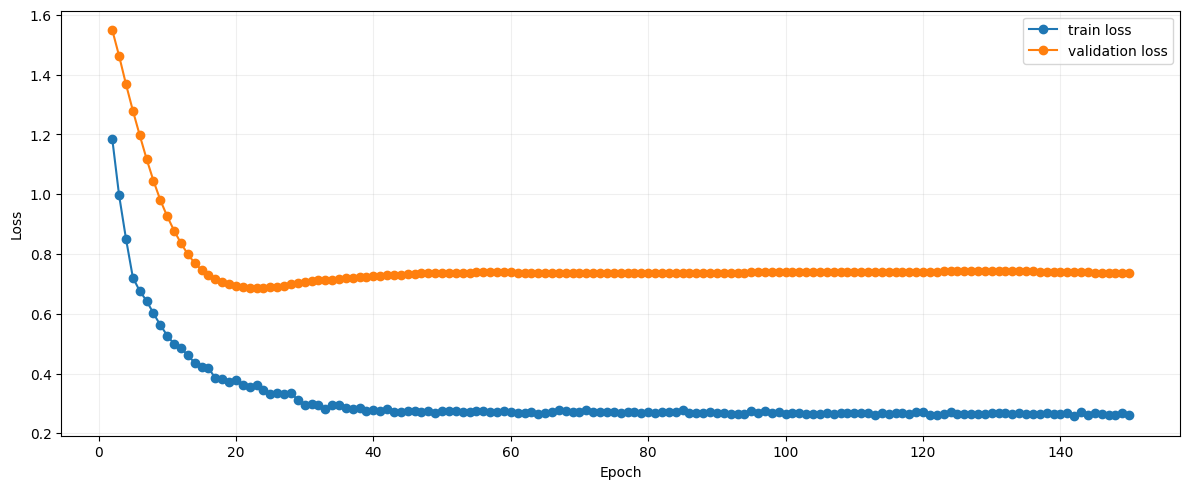

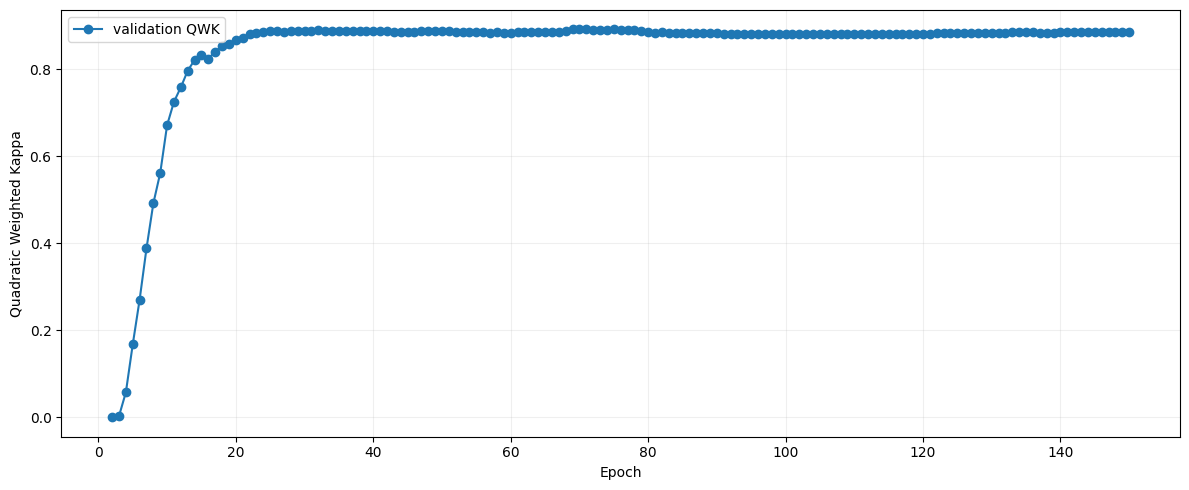

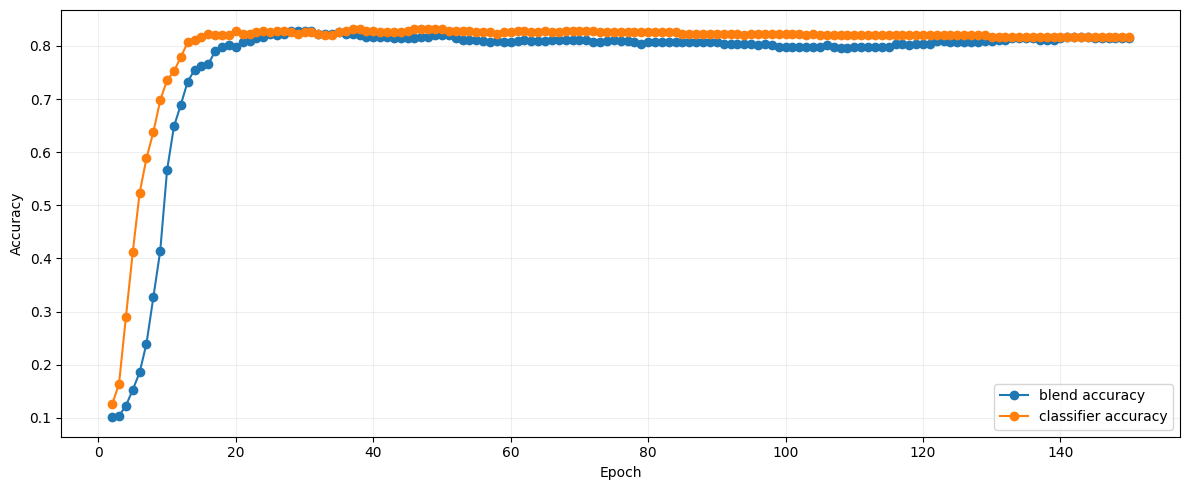

,epoch,train_loss,train_cls_loss,train_reg_loss,val_loss,val_qwk,val_accuracy,val_classifier_accuracy,val_balanced_accuracy,val_macro_f1,backbone_lr,head_lr,no_improve_epochs,minutes
134,136,0.264123,0.339712,0.037356,0.741521,0.885780,0.814714,0.817439,0.604631,0.620074,8.000000e-07,0.000004,67,5.176964
135,137,0.263592,0.338822,0.037903,0.741265,0.884742,0.811989,0.817439,0.603526,0.617783,8.000000e-07,0.000004,68,5.133619
136,138,0.266951,0.343383,0.037656,0.740982,0.884742,0.811989,0.817439,0.603526,0.617783,8.000000e-07,0.000004,69,5.146968
137,139,0.265512,0.342516,0.034499,0.740646,0.884742,0.811989,0.817439,0.603526,0.617783,8.000000e-07,0.000004,70,5.103465
138,140,0.263748,0.339979,0.035055,0.740342,0.885364,0.814714,0.817439,0.605526,0.620731,8.000000e-07,0.000004,71,5.104066
139,141,0.267637,0.344479,0.037111,0.739928,0.886197,0.817439,0.817439,0.610932,0.625785,8.000000e-07,0.000004,72,5.167385
140,142,0.256508,0.331020,0.032971,0.739020,0.886197,0.817439,0.817439,0.610932,0.625785,8.000000e-07,0.000004,73,5.191470
141,143,0.269988,0.346760,0.039670,0.738702,0.886197,0.817439,0.817439,0.610932,0.625785,8.000000e-07,0.000004,74,5.225520
142,144,0.262188,0.338192,0.034176,0.738120,0.886404,0.817439,0.817439,0.606631,0.623022,8.000000e-07,0.000004,75,5.219137
143,145,0.268992,0.346499,0.036471,0.737956,0.885364,0.814714,0.817439,0.605526,0.620731,8.000000e-07,0.000004,76,5.086472


In [14]:
# ============================================================
# 14. Plot training history
# ============================================================
if HISTORY_PATH.exists():
    hist = pd.read_csv(HISTORY_PATH)
elif len(history) > 0:
    hist = pd.DataFrame(history)
else:
    raise RuntimeError("No history yet. Run cell 13 first and let at least one epoch finish.")

plt.figure(figsize=(12, 5))
plt.plot(hist["epoch"], hist["train_loss"], marker="o", label="train loss")
plt.plot(hist["epoch"], hist["val_loss"], marker="o", label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loss_curve.png", dpi=160)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(hist["epoch"], hist["val_qwk"], marker="o", label="validation QWK")
plt.xlabel("Epoch")
plt.ylabel("Quadratic Weighted Kappa")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "qwk_curve.png", dpi=160)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(hist["epoch"], hist["val_accuracy"], marker="o", label="blend accuracy")
plt.plot(hist["epoch"], hist["val_classifier_accuracy"], marker="o", label="classifier accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "accuracy_curve.png", dpi=160)
plt.show()

display(hist.tail(15))

In [15]:
# ============================================================
# 15. Load best checkpoint and evaluate validation set
# ============================================================
best_ckpt = safe_torch_load(
    BEST_PATH,
    map_location=DEVICE,
)

model.load_state_dict(
    best_ckpt["model_ema"]
)
model.eval()

val_metrics, y_val, val_cont, val_cls_pred = validate(
    model,
    valid_loader,
)

val_pred_default = round_default(val_cont)

print("Best checkpoint epoch:", int(best_ckpt["epoch"]) + 1)

print("\nContinuous-blend default metrics:")
for k, v in val_metrics.items():
    print(f"  {k}: {v:.5f}")

print("\nClassifier-head report:")
print(
    classification_report(
        y_val,
        val_cls_pred,
        digits=4,
        zero_division=0,
    )
)

cm = confusion_matrix(y_val, val_cls_pred)

display(pd.DataFrame(
    cm,
    index=[f"true_{i}" for i in range(CFG["n_classes"])],
    columns=[f"pred_{i}" for i in range(CFG["n_classes"])],
))

pd.DataFrame({
    "id_code": va_df["id_code"],
    "true": y_val,
    "continuous_prediction": val_cont,
    "blend_rounded_prediction": val_pred_default,
    "classifier_prediction": val_cls_pred,
}).to_csv(
    OUTPUT_DIR / "validation_predictions.csv",
    index=False,
)


Evaluate:   0%|          | 0/6 [00:00<?, ?it/s]

Best checkpoint epoch: 69

Continuous-blend default metrics:
  qwk: 0.89195
  accuracy: 0.81199
  balanced_accuracy: 0.63000
  macro_f1: 0.63033
  loss: 0.73724
  classifier_accuracy: 0.82834
  classifier_qwk: 0.86757

Classifier-head report:
              precision    recall  f1-score   support

           0     0.9783    0.9945    0.9863       181
           1     0.6667    0.5405    0.5970        37
           2     0.7311    0.8700    0.7945       100
           3     0.4000    0.3158    0.3529        19
           4     0.5789    0.3667    0.4490        30

    accuracy                         0.8283       367
   macro avg     0.6710    0.6175    0.6360       367
weighted avg     0.8169    0.8283    0.8181       367



,pred_0,pred_1,pred_2,pred_3,pred_4
true_0,180,1,0,0,0
true_1,1,20,15,0,1
true_2,2,5,87,2,4
true_3,0,2,8,6,3
true_4,1,2,9,7,11


In [16]:
# ============================================================
# 16. Validation-only threshold tuning + prediction strategy selection
# ============================================================
DEFAULT_THRESHOLDS = np.array([0.5, 1.5, 2.5, 3.5], dtype=np.float64)
opt_thresholds = DEFAULT_THRESHOLDS.copy()
opt_qwk = qwk_score(y_val, val_pred_default)

if SCIPY_AVAILABLE:
    try:
        def apply_thresholds(preds, coef):
            coef = np.sort(np.asarray(coef, dtype=np.float64))
            return np.digitize(preds, bins=coef).astype(int)

        def objective(coef):
            pred = apply_thresholds(val_cont, coef)
            return -qwk_score(y_val, pred)

        result = minimize(
            objective,
            DEFAULT_THRESHOLDS,
            method="Nelder-Mead",
            options={
                "maxiter": 1200,
                "xatol": 1e-4,
                "fatol": 1e-4,
            },
        )

        candidate = np.sort(np.asarray(result.x, dtype=np.float64))
        candidate_pred = apply_thresholds(val_cont, candidate)
        candidate_qwk = qwk_score(y_val, candidate_pred)

        if np.isfinite(candidate_qwk) and candidate_qwk >= opt_qwk:
            opt_thresholds = candidate
            opt_qwk = candidate_qwk

    except Exception as e:
        print("WARNING: threshold optimization failed; defaults will be used.")
        print("Threshold error:", repr(e))
else:
    print("SciPy unavailable; using default thresholds.")

val_pred_thresholded = np.digitize(
    val_cont,
    bins=np.sort(opt_thresholds),
).astype(int)

def metrics_from_labels(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "qwk": qwk_score(y_true, y_pred),
    }

strategy_table = pd.DataFrame([
    {"strategy": "classifier_argmax", **metrics_from_labels(y_val, val_cls_pred)},
    {"strategy": "blend_round", **metrics_from_labels(y_val, val_pred_default)},
    {"strategy": "blend_tuned_thresholds", **metrics_from_labels(y_val, val_pred_thresholded)},
]).sort_values(
    ["accuracy", "qwk"],
    ascending=False,
).reset_index(drop=True)

display(strategy_table)

# User specifically wants high test accuracy, so prediction mode is selected
# using VALIDATION accuracy only. Held-out test remains untouched.
SELECTED_STRATEGY = str(strategy_table.iloc[0]["strategy"])

print("Selected validation strategy:", SELECTED_STRATEGY)
print("Selected thresholds:", opt_thresholds)
print("Validation QWK with tuned thresholds:", round(float(opt_qwk), 6))

with open(OUTPUT_DIR / "prediction_strategy.json", "w") as f:
    json.dump({
        "selected_strategy": SELECTED_STRATEGY,
        "thresholds": opt_thresholds.tolist(),
        "validation_results": strategy_table.to_dict(orient="records"),
        "best_epoch": int(best_ckpt["epoch"]) + 1,
    }, f, indent=2)


,strategy,accuracy,balanced_accuracy,macro_f1,qwk
0,blend_tuned_thresholds,0.833787,0.664643,0.663789,0.898916
1,classifier_argmax,0.828338,0.617494,0.635952,0.867574
2,blend_round,0.811989,0.630000,0.630332,0.891948


Selected validation strategy: blend_tuned_thresholds
Selected thresholds: [0.53436696 1.65436561 2.42178523 3.52340076]
Validation QWK with tuned thresholds: 0.898916


In [17]:
# ============================================================
# 17. ONE-TIME held-out test evaluation
# ============================================================
held_metrics_blend, y_test, test_cont, test_cls_pred = validate(
    model,
    heldout_loader,
)

if SELECTED_STRATEGY == "classifier_argmax":
    test_pred = test_cls_pred
elif SELECTED_STRATEGY == "blend_round":
    test_pred = round_default(test_cont)
elif SELECTED_STRATEGY == "blend_tuned_thresholds":
    test_pred = np.digitize(
        test_cont,
        bins=np.sort(opt_thresholds),
    ).astype(int)
else:
    raise ValueError("Unknown prediction strategy.")

heldout_metrics = metrics_from_labels(
    y_test,
    test_pred,
)

print("=" * 70)
print("FINAL HELD-OUT TEST RESULTS")
print("=" * 70)
print("Prediction strategy:", SELECTED_STRATEGY)

for k, v in heldout_metrics.items():
    print(f"{k:20s}: {v:.5f}")

print(
    "\n90% accuracy target:",
    "REACHED" if heldout_metrics["accuracy"] >= 0.90 else "NOT REACHED"
)

print("\nHeld-out classification report:")
print(
    classification_report(
        y_test,
        test_pred,
        digits=4,
        zero_division=0,
    )
)

test_cm = confusion_matrix(y_test, test_pred)
display(pd.DataFrame(
    test_cm,
    index=[f"true_{i}" for i in range(CFG["n_classes"])],
    columns=[f"pred_{i}" for i in range(CFG["n_classes"])],
))

pd.DataFrame({
    "id_code": heldout_df["id_code"],
    "true": y_test,
    "continuous_prediction": test_cont,
    "classifier_prediction": test_cls_pred,
    "final_prediction": test_pred,
}).to_csv(
    OUTPUT_DIR / "heldout_test_predictions.csv",
    index=False,
)

with open(OUTPUT_DIR / "heldout_test_metrics.json", "w") as f:
    json.dump(heldout_metrics, f, indent=2)


Evaluate:   0%|          | 0/6 [00:00<?, ?it/s]

FINAL HELD-OUT TEST RESULTS
Prediction strategy: blend_tuned_thresholds
accuracy            : 0.81199
balanced_accuracy   : 0.61017
macro_f1            : 0.62895
qwk                 : 0.91342

90% accuracy target: NOT REACHED

Held-out classification report:
              precision    recall  f1-score   support

           0     0.9676    0.9890    0.9781       181
           1     0.6538    0.4595    0.5397        37
           2     0.7130    0.8200    0.7628       100
           3     0.2727    0.3158    0.2927        19
           4     0.7368    0.4667    0.5714        30

    accuracy                         0.8120       367
   macro avg     0.6688    0.6102    0.6289       367
weighted avg     0.8118    0.8120    0.8065       367



,pred_0,pred_1,pred_2,pred_3,pred_4
true_0,179,1,1,0,0
true_1,6,17,14,0,0
true_2,0,8,82,9,1
true_3,0,0,9,6,4
true_4,0,0,9,7,14


In [18]:
# ============================================================
# 18. Optional official APTOS test prediction / Kaggle submission
# ============================================================
@torch.no_grad()
def predict_tta(model_to_eval, loader, use_tta=True):
    model_to_eval.eval()

    all_ids = []
    all_cont = []
    all_probs = []

    for images, ids in tqdm(loader, desc="Official test prediction"):
        images = move_images(images)

        def forward_both(x):
            with autocast_context():
                logits, severity = model_to_eval(x)
                cont = blend_continuous_predictions(logits, severity)
                probs = torch.softmax(logits, dim=1)
                return cont, probs

        cont0, probs0 = forward_both(images)
        cont_preds = [cont0]
        prob_preds = [probs0]

        if use_tta:
            cont1, probs1 = forward_both(torch.flip(images, dims=[3]))
            cont_preds.append(cont1)
            prob_preds.append(probs1)

        cont = torch.stack(cont_preds, dim=0).mean(dim=0)
        probs = torch.stack(prob_preds, dim=0).mean(dim=0)

        all_cont.extend(cont.float().cpu().numpy().tolist())
        all_probs.append(probs.float().cpu().numpy())
        all_ids.extend(list(ids))

    return (
        np.asarray(all_ids),
        np.asarray(all_cont, dtype=np.float32),
        np.concatenate(all_probs, axis=0),
    )

if test_df is None:
    print("No complete official APTOS test set detected; submission generation skipped.")
else:
    official_test_ds = AptosDataset(
        test_df,
        valid_tfms,
        is_test=True,
    )

    official_test_loader = make_loader(
        official_test_ds,
        CFG["batch_size"] * 2,
        shuffle=False,
        drop_last=False,
    )

    ids, official_cont, official_probs = predict_tta(
        model,
        official_test_loader,
        use_tta=CFG["tta"],
    )

    if SELECTED_STRATEGY == "classifier_argmax":
        official_pred = np.argmax(official_probs, axis=1).astype(int)
    elif SELECTED_STRATEGY == "blend_round":
        official_pred = round_default(official_cont)
    else:
        official_pred = np.digitize(
            official_cont,
            bins=np.sort(opt_thresholds),
        ).astype(int)

    submission = pd.DataFrame({
        "id_code": ids,
        "diagnosis": official_pred,
    })

    if sample_csv is not None:
        sample = pd.read_csv(sample_csv)
        sample["id_code"] = sample["id_code"].astype(str)

        submission = sample[["id_code"]].merge(
            submission,
            on="id_code",
            how="left",
        )

        if submission["diagnosis"].isna().any():
            raise RuntimeError("Submission merge produced missing predictions.")

        submission["diagnosis"] = submission["diagnosis"].astype(int)

    submission.to_csv(
        OUTPUT_DIR / "submission.csv",
        index=False,
    )

    print("Submission shape:", submission.shape)
    display(submission.head())
    display(submission["diagnosis"].value_counts().sort_index())


Official test prediction:   0%|          | 0/31 [00:00<?, ?it/s]

Submission shape: (1928, 2)


,id_code,diagnosis
0,0005cfc8afb6,2
1,003f0afdcd15,2
2,006efc72b638,3
3,00836aaacf06,2
4,009245722fa4,2


diagnosis
0     208
1     342
2    1061
3     285
4      32
Name: count, dtype: int64

In [19]:
# ============================================================
# 19. Final output verification
# ============================================================
required_weight_files = [
    BEST_WEIGHTS_PATH,
    BEST_VAL_WEIGHTS_PATH,
    FINAL_WEIGHTS_PATH,
]

print("Standalone Kaggle Output weight files:")
for p in required_weight_files:
    if not p.exists():
        raise FileNotFoundError(f"Expected weight file was not created: {p}")

    size_mb = p.stat().st_size / (1024 ** 2)
    print(f"{p.name:52s} {size_mb:8.2f} MB")

print("\nTraining-folder files:")
for p in sorted(OUTPUT_DIR.glob("*")):
    size_mb = p.stat().st_size / (1024 ** 2)
    print(f"{p.name:52s} {size_mb:8.2f} MB")

print("\nRECOMMENDED inference/deployment weights:")
print(BEST_WEIGHTS_PATH)

print("\nSelected prediction strategy:")
print(SELECTED_STRATEGY)

print("\nHeld-out test accuracy:")
print(f"{heldout_metrics['accuracy']:.4%}")


Standalone Kaggle Output weight files:
aptos_resnet34_fast_best_weights.pth                    81.85 MB
aptos_resnet34_fast_best_val_loss_weights.pth           81.85 MB
aptos_resnet34_fast_last_epoch_weights.pth              81.85 MB

Training-folder files:
accuracy_curve.png                                       0.06 MB
best_full_checkpoint.pth                               327.22 MB
config.json                                              0.00 MB
data_split.csv                                           0.08 MB
heldout_test_metrics.json                                0.00 MB
heldout_test_predictions.csv                             0.01 MB
last_full_checkpoint.pth                               327.23 MB
loss_curve.png                                           0.05 MB
prediction_strategy.json                                 0.00 MB
qwk_curve.png                                            0.04 MB
submission.csv                                           0.03 MB
training_history.csv       

## Final ResNet34 150-epoch faster configuration

- Architecture: **ResNet34 dual-head classification + ordinal regression**
- Input resolution: **300 × 300**
- Epochs: **150 full epochs**
- Training batch: **automatic; normally 32 on a 16 GB Kaggle GPU**
- Validation/test batch: **2× training batch**
- Backbone frozen: **first 3 epochs**
- Frozen-stage head LR: **4e-4**
- Fine-tuning backbone LR: **4e-5**
- Fine-tuning head LR: **2e-4**
- LR scheduler: **ReduceLROnPlateau**
  - factor: 0.5
  - patience: 2
- AdamW weight decay: **3e-4**
- Dropout: **0.35**
- Label smoothing: **0.05**
- EMA decay: **0.999**
- Classification/regression loss: **0.75 / 0.25**
- AMP mixed precision
- CUDA channels-last layout
- Fused AdamW when supported
- Pinned memory
- Persistent DataLoader workers
- Prefetch factor: **4**
- Moderate class weighting
- Conservative retinal augmentation
- Gradient clipping
- Best-QWK EMA checkpointing
- Validation-only prediction-strategy selection
- Final untouched held-out test evaluation
- Fresh training from epoch 1

### Why this should train faster
The full 150 epochs are still executed. The main wall-clock reduction comes from processing more images per GPU step (batch ~32 instead of 16) and reducing data/optimizer overhead. The higher-but-conservative LR is intended to match the larger batch and reach useful performance faster without blindly doubling the learning rate.

### Fresh start
This notebook intentionally ignores previous checkpoints and starts training from epoch 1 with the new faster batch-size and learning-rate configuration.

### Recommended deployment weights
`/kaggle/working/aptos_resnet34_fast_best_weights.pth`

This is the best validation EMA checkpoint, not simply the epoch-150 model.
